# The Central Limit Theorem (CLT)

## CLT Definition
As you take sufficiently large random samples from any population, the distribution of the sample means will always be approximately normal, even if the original population itself is not normally distributed.

## Assumptions
<ol style="margin-bottom: 0;">
  <li><b>Sampling is random.</b></li>
  <li><b>Independent and identically distributed samples (i.i.d).</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li><i>Independent</i> - Observing one data sample doesn't provide information about the next. (i.e. two rolls of a fair dice — the first roll doesn't impact the second)</li>
      <li><i>Identically distributed</i> - All samples are generated by the same process and from the same underlying distribution.</li>
      <li>Random sampling generally gaurantees i.i.d.</li>
    </ul>
  </li>
  <li><b>Sufficient N.</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Classically this means N > 30. But remember the more skewed the population distribution, the more samples we will need for the limit to converge.</li>
      <li>Sample size < 10% of population if sampling without replacement.</li>
      <li>Modern computing allows more nuance than old lookup tables.</li>
    </ul>
  </li>
  <li><b>The population has a finite mean and variance.</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>See examples for more on how sample size and variance can affect CLT conversion.</li>
    </ul>
  </li>
</ol>

## Why is the CLT important?
1. **Cost saving** - We can infer about the population without having to sample all or most of the population.
2. **Experimentation** - We don't need to know the underlying population distribution and with statistical testing we can have confidence in our change (determine if our change was statistically significant).

## What does the distribution of the sample means look like?
As we take sufficiently large samples, the distribution of the sample mean converges to the population mean.
$$\bar{x} \rightarrow \mu$$
And the sample variance converges to the population variance divided by $n-1$.
$$s^2 \rightarrow \frac{\sigma^2}{n-1}$$

\*Note: We divide by $n-1$ to account for the bias in measuring the sample variance. $n-1$ lowers the degrees of freedom to do this.

## Examples

In [1]:
# imports
import pandas as pd
import numpy as np
from scipy.stats import uniform
from scipy.stats import norm
from scipy.stats import cauchy
import seaborn as sns
import matplotlib.pyplot as plt

# function calculates the sample mean and variance for a sample of size n
def sample_mean_var(dist: np.array([float]), n: int) -> float:
    # sample from the population distribution
    rng = np.random.default_rng()
    sample = rng.choice(dist, size=n, replace=True)

    # calculate the sample mean and variance
    mean = sample.mean()
        
    return mean

# function creates the sampling distributions of the mean and variance 
# (collection of means and variances from samples of size n)
def distribution_sample(dist: np.array([float]), n:int, n_samples=1001) -> tuple[np.array([float])]:
    # create empty arrays to hold distribution of sampling mean and variance
    sample_means = np.array([])
    
    for i in range(1, n_samples):
        sample_mean = sample_mean_var(dist, n)
        
        # append the values to the array
        sample_means = np.append(sample_means, sample_mean)
        
    return sample_means 

### Population Described by Uniform Distribution
We know the mean of a continuous uniform distribution is: \
$$\mu = \frac{a + b}{2}$$
So for a continuous distribution where $0 \leq x \leq 1$, $\mu = 0.50$.

We also know that the variance of a coninuous uniform distribution is: \
$$\sigma^2 = \frac{(b - a)^2}{12}$$
So for a continuous distribution where $0 \leq x \leq 1$, $\sigma^2 \approx 0.83$. 

**Let's use the CLT along with bootstrapping to manually show the distribution of the sampling mean converging to the true values.**

In [2]:
# assume population total is 1M
N = 1E6

# assume population statistic is uniformly distributed 
uniform_dist = uniform.rvs(loc=0, scale=1, size=int(N))

The uniform distribution looks like the following.

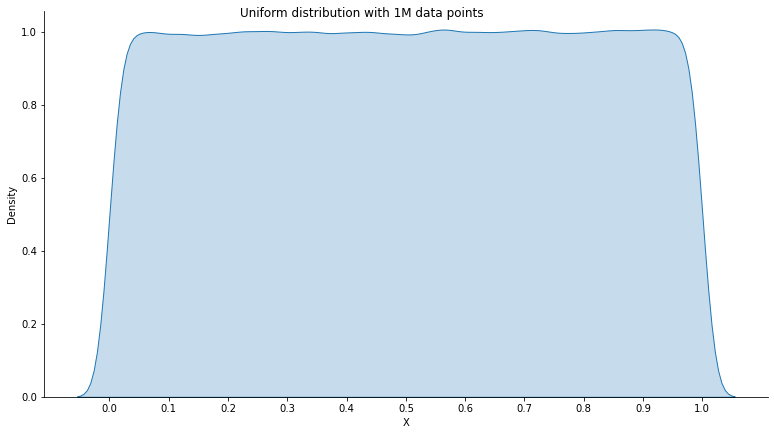

In [3]:
# plot the uniform distribution with 1M data points
ax = sns.displot(data=uniform_dist, kind='kde', fill=True)
ax.fig.suptitle('Uniform distribution with 1M data points')
ax.set_xlabels('X')
ax.fig.set_size_inches(12, 6)

custom_ticks = np.arange(0, 1.1, 0.1, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

In [4]:
# create dataframe to store the data
uniform_df = pd.DataFrame()

# loop over different sample sizes to show how they affect convergence rate
for n in [5, 10, 30, 100]:
    sample_means = distribution_sample(uniform_dist, n, n_samples=10001)
    sample_sizes = n

    # create the df for each sample size
    sample_df = pd.DataFrame()
    sample_df['sample_mean'] = sample_means
    sample_df['sample_sizes'] = n
    
    # append to full df
    uniform_df = pd.concat([uniform_df, sample_df], ignore_index=True)

**The distribution of the sample means converges faster as we increase the sample size for each sample.**

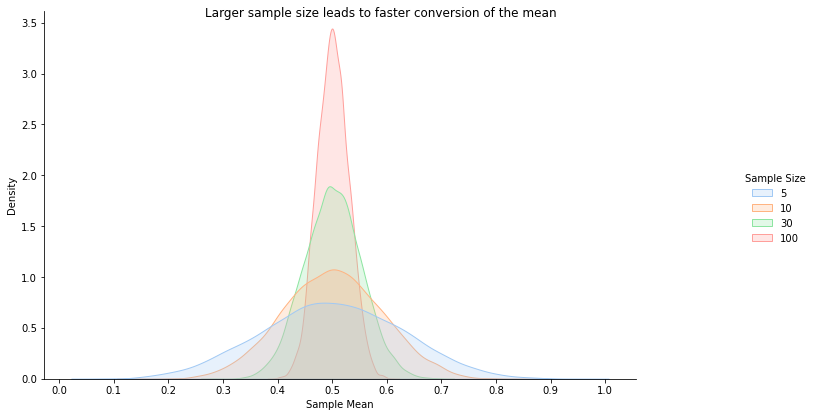

In [5]:
# plot overlapping distributions for the sample means
ax = sns.displot(data=uniform_df, x='sample_mean', kind='kde', fill=True, hue='sample_sizes', palette='pastel')
ax.fig.suptitle('Larger sample size leads to faster conversion of the mean')
ax.set_xlabels('Sample Mean')
ax.legend.set_title('Sample Size')
ax.fig.set_size_inches(12, 6)

custom_ticks = np.arange(0, 1.1, 0.1, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

### Population Described by Normal Distribution

In [6]:
# assume population statistic is normally distributed 
normal_dist = norm.rvs(loc=0, scale=1, size=int(N))

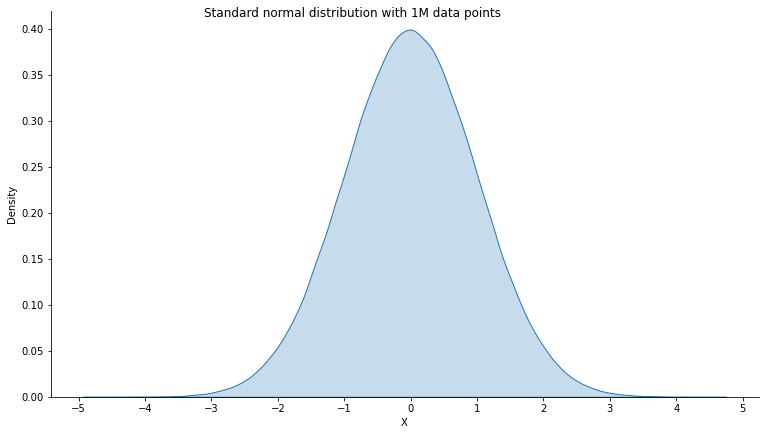

In [7]:
# plot the normal distribution with 1M data points
ax = sns.displot(data=normal_dist, kind='kde', fill=True)
ax.fig.suptitle('Standard normal distribution with 1M data points')
ax.set_xlabels('X')
ax.fig.set_size_inches(12, 6)

custom_ticks = np.arange(-5, 6, 1, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

In [8]:
# create dataframe to store the data
normal_df = pd.DataFrame()

# loop over different standard deviations to show how they affect convergence rate
for sd in [1, 2, 5, 10]:
    norm_dist = norm.rvs(loc=0, scale=sd, size=int(N))
    sample_means = distribution_sample(norm_dist, 10, n_samples=10001)

    # create the df for each sample size
    sample_df = pd.DataFrame()
    sample_df['sample_mean'] = sample_means
    sample_df['sample_sd'] = sd
    
    # append to full df
    normal_df = pd.concat([normal_df, sample_df], ignore_index=True)

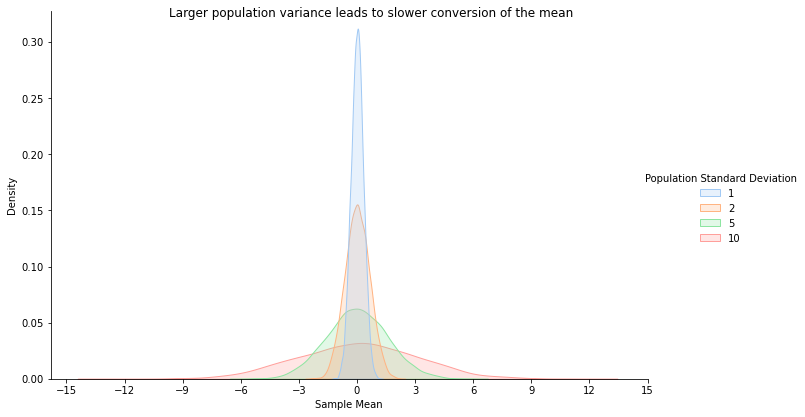

In [9]:
# plot overlapping distributions for the sample means
ax = sns.displot(data=normal_df, x='sample_mean', kind='kde', fill=True, hue='sample_sd', palette='pastel')
ax.fig.suptitle('Larger population variance leads to slower conversion of the mean')
ax.set_xlabels('Sample Mean')
ax.legend.set_title('Population Standard Deviation')
ax.fig.set_size_inches(12, 6)

custom_ticks = np.arange(-15, 16, 3, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

### Population Described by Cauchy Distribution

In [10]:
# assume population statistic follows a Cauchy distribution
cauchy_dist = cauchy.rvs(loc=0, scale=0.01, size=int(N))

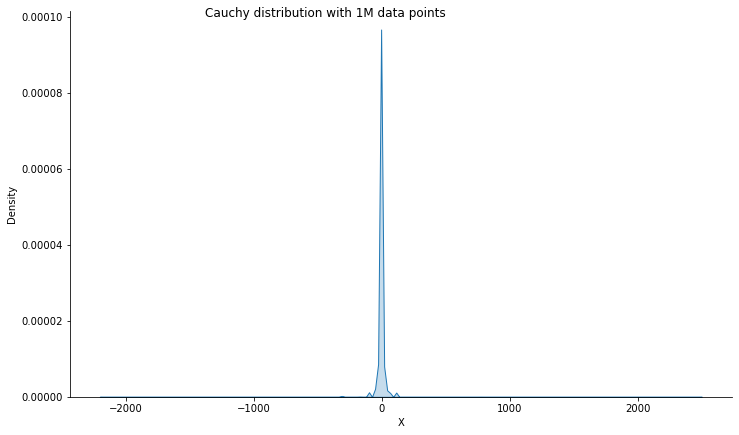

In [11]:
# plot the Cauchy distribution with 1M data points
ax = sns.displot(data=cauchy_dist, kind='kde', fill=True)
ax.fig.suptitle('Cauchy distribution with 1M data points')
ax.set_xlabels('X')
ax.fig.set_size_inches(12, 6)

plt.show()

In [12]:
# create dataframe to store the data
cauchy_df = pd.DataFrame()

# loop over different standard deviations to show how they affect convergence rate
for gamma in [0.01, 0.1, 1, 10]:
    cauchy_dist = cauchy.rvs(loc=0, scale=gamma, size=int(N))
    sample_means = distribution_sample(cauchy_dist, 10, n_samples=10001)

    # create the df for each sample size
    sample_df = pd.DataFrame()
    sample_df['sample_mean'] = sample_means
    sample_df['sample_gamma'] = gamma
    
    # append to full df
    cauchy_df = pd.concat([cauchy_df, sample_df], ignore_index=True)

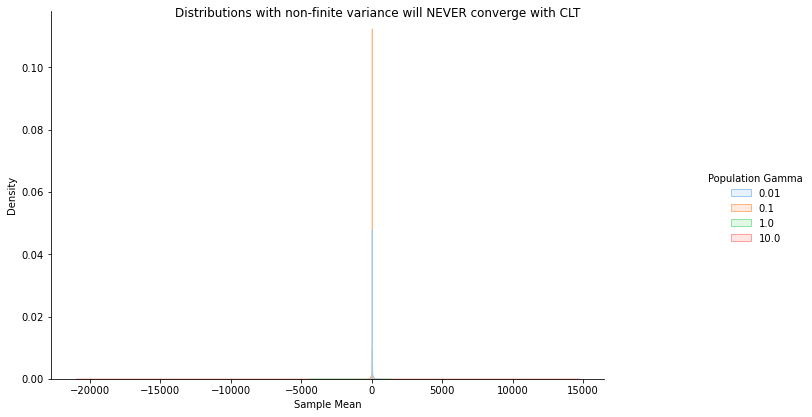

In [13]:
# plot overlapping distributions for the sample means
ax = sns.displot(data=cauchy_df, x='sample_mean', kind='kde', fill=True, hue='sample_gamma', palette='pastel')
ax.fig.suptitle('Distributions with non-finite variance will NEVER converge with CLT')
ax.set_xlabels('Sample Mean')
ax.legend.set_title('Population Gamma')
ax.fig.set_size_inches(12, 6)

plt.show()